In [9]:


from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt



In [8]:
arq = Path("arq.nc")

ds = xr.open_dataset(arq, engine="netcdf4")
print(ds)


band = ds["Band1"]

print("min:", float(band.min()))
print("max:", float(band.max()))
print("mean:", float(band.mean()))
print("attrs:", band.attrs)

<xarray.Dataset> Size: 78MB
Dimensions:  (lat: 3131, lon: 3131)
Coordinates:
  * lat      (lat) float64 25kB -55.99 -55.96 -55.93 -55.9 ... 34.93 34.96 34.99
  * lon      (lon) float64 25kB -116.0 -116.0 -115.9 ... -25.07 -25.04 -25.01
Data variables:
    Band1    (lat, lon) float64 78MB ...
    crs      |S1 1B ...
Attributes:
    Conventions:  CF-1.5
    GDAL:         GDAL 2.2.2, released 2017/09/15
    history:      Sat Jul 01 00:16:29 2023: GDAL Create( /dados/output/goes16...
min: 18456.0
max: 31994.0
mean: 27604.287864597958
attrs: {'long_name': 'GDAL Band Number 1', 'grid_mapping': 'crs'}


In [10]:

# ============================================================
# CONVERTER BAND1 PARA TEMPERATURA DE BRILHO EM K
# ============================================================

tb = ds["Band1"].astype("float32") / 100.0

print("Tb min:", float(tb.min()))
print("Tb max:", float(tb.max()))
print("Tb mean:", float(tb.mean()))

# ============================================================
# COORDENADAS DO ATTO/CAMPINA
# 2°10'53.7"S, 59°01'18.7"W
# ============================================================

LAT_ATTO = -(2 + 10/60 + 53.7/3600)
LON_ATTO = -(59 + 1/60 + 18.7/3600)

print("LAT_ATTO:", LAT_ATTO)
print("LON_ATTO:", LON_ATTO)

# ============================================================
# RESOLUÇÃO APROXIMADA DO GRID
# ============================================================

lat = ds["lat"].values
lon = ds["lon"].values

dlat = np.nanmedian(np.abs(np.diff(lat)))
dlon = np.nanmedian(np.abs(np.diff(lon)))

dy_km = dlat * 111.32
dx_km = dlon * 111.32 * np.cos(np.deg2rad(LAT_ATTO))

area_pixel_km2 = dx_km * dy_km

print(f"dlat = {dlat:.5f} grau ≈ {dy_km:.2f} km")
print(f"dlon = {dlon:.5f} grau ≈ {dx_km:.2f} km")
print(f"Área aproximada do pixel = {area_pixel_km2:.2f} km²")

Tb min: 184.55999755859375
Tb max: 319.94000244140625
Tb mean: 276.0428771972656
LAT_ATTO: -2.181583333333333
LON_ATTO: -59.02186111111111
dlat = 0.02906 grau ≈ 3.24 km
dlon = 0.02906 grau ≈ 3.23 km
Área aproximada do pixel = 10.46 km²


recorte em torno do atto

<xarray.DataArray 'Band1' (lat: 69, lon: 69)> Size: 19kB
array([[295.61, 295.79, 294.93, ..., 289.71, 289.83, 290.01],
       [295.61, 295.36, 295.36, ..., 291.67, 291.18, 290.2 ],
       [295.3 , 294.99, 294.44, ..., 291.  , 290.2 , 288.23],
       ...,
       [245.15, 245.95, 247.55, ..., 277.29, 271.15, 270.35],
       [246.32, 250.19, 252.22, ..., 273.91, 269.3 , 266.72],
       [250.87, 255.17, 255.11, ..., 264.39, 266.17, 263.9 ]],
      shape=(69, 69), dtype=float32)
Coordinates:
  * lat      (lat) float64 552B -3.176 -3.147 -3.118 ... -1.258 -1.229 -1.199
  * lon      (lon) float64 552B -60.01 -59.98 -59.95 ... -58.09 -58.06 -58.03
Attributes:
    long_name:     GDAL Band Number 1
    grid_mapping:  crs
shape do recorte: (69, 69)
Tb min no recorte: 205.63999938964844
Tb max no recorte: 296.5899963378906


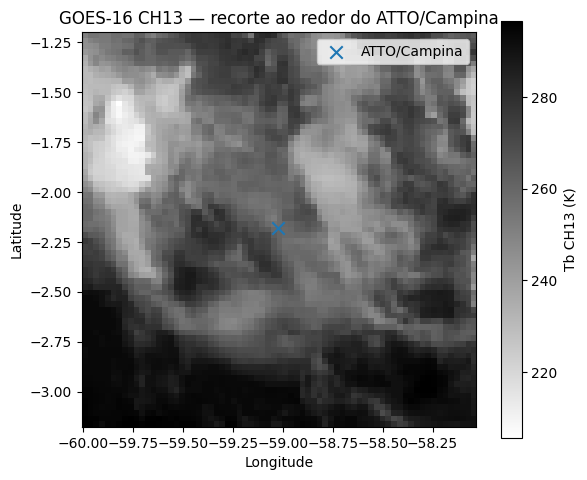

In [12]:
# ============================================================
# RECORTE AO REDOR DO ATTO
# ============================================================

raio_graus = 1.0

lat_min = LAT_ATTO - raio_graus
lat_max = LAT_ATTO + raio_graus
lon_min = LON_ATTO - raio_graus
lon_max = LON_ATTO + raio_graus

patch = tb.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

print(patch)
print("shape do recorte:", patch.shape)
print("Tb min no recorte:", float(patch.min()))
print("Tb max no recorte:", float(patch.max()))

plt.figure(figsize=(6, 5))

plt.imshow(
    patch.values,
    origin="lower",
    cmap="gray_r",
    extent=[
        float(patch.lon.min()),
        float(patch.lon.max()),
        float(patch.lat.min()),
        float(patch.lat.max())
    ]
)

plt.colorbar(label="Tb CH13 (K)")
plt.scatter(LON_ATTO, LAT_ATTO, marker="x", s=80, label="ATTO/Campina")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GOES-16 CH13 — recorte ao redor do ATTO/Campina")
plt.legend()
plt.tight_layout()
plt.show()

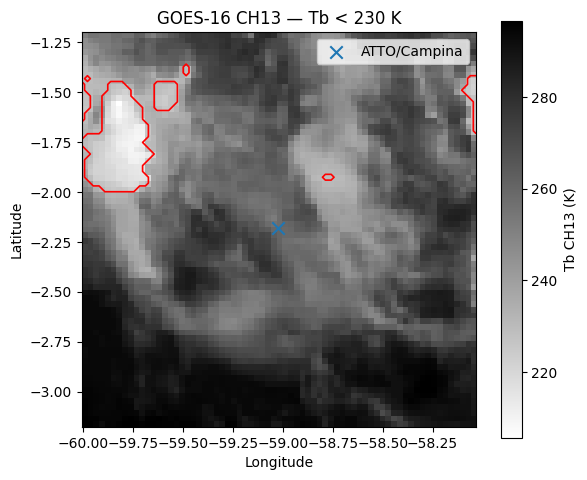

In [14]:
# ============================================================
# PLOT COM CONTORNO Tb < 230 K
# ============================================================

LIMIAR_TB = 230.0

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    patch.values,
    origin="lower",
    cmap="gray_r",
    extent=[
        float(patch.lon.min()),
        float(patch.lon.max()),
        float(patch.lat.min()),
        float(patch.lat.max())
    ]
)

# Máscara de nuvem profunda
mask_frio = patch.values < LIMIAR_TB

# Só desenha contorno se existir pelo menos um pixel frio
if np.any(mask_frio):
    ax.contour(
        patch.lon.values,
        patch.lat.values,
        mask_frio,
        levels=[0.5],
        colors="red",
        linewidths=1.2
    )
else:
    print("Não há pixels com Tb < 230 K neste recorte.")

# Colorbar associada ao imshow, não ao contour
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Tb CH13 (K)")

ax.scatter(
    LON_ATTO,
    LAT_ATTO,
    marker="x",
    s=80,
    label="ATTO/Campina"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("GOES-16 CH13 — Tb < 230 K")
ax.legend()

plt.tight_layout()
plt.show()

0 = sem nuvem profunda no recorte
1 = nuvem profunda distante
2 = nuvem profunda próxima da antena
3 = nuvem profunda sobre a antena

In [15]:
mask_frio = patch.values < 230.0

n_pixels_frios = np.sum(mask_frio)
area_fria_total_km2 = n_pixels_frios * area_pixel_km2
frac_fria = np.mean(mask_frio)

print("Número de pixels Tb < 230 K:", n_pixels_frios)
print(f"Área total Tb < 230 K: {area_fria_total_km2:.1f} km²")
print(f"Fração do patch com Tb < 230 K: {frac_fria:.3f}")
print("Tem nuvem profunda?", area_fria_total_km2 >= 3000)

Número de pixels Tb < 230 K: 206
Área total Tb < 230 K: 2154.8 km²
Fração do patch com Tb < 230 K: 0.043
Tem nuvem profunda? False


In [16]:
import numpy as np
import pandas as pd
from scipy.ndimage import label

# ============================================================
# FUNÇÃO HAVERSINE
# ============================================================

def haversine_km(lat1, lon1, lat2, lon2):
    """
    Distância aproximada entre pontos geográficos em km.
    Aceita escalares ou arrays.
    """
    R = 6371.0

    lat1 = np.deg2rad(lat1)
    lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2)
    lon2 = np.deg2rad(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


# ============================================================
# IDENTIFICAR OBJETOS COM Tb < 230 K
# ============================================================

LIMIAR_TB = 230.0

mask_frio = patch.values < LIMIAR_TB

# conexão 8-vizinhos: considera diagonal
estrutura = np.ones((3, 3), dtype=int)

labels, n_objetos = label(mask_frio, structure=estrutura)

lat2d, lon2d = np.meshgrid(
    patch.lat.values,
    patch.lon.values,
    indexing="ij"
)

objetos = []

for obj_id in range(1, n_objetos + 1):

    mask_obj = labels == obj_id

    n_pix = np.sum(mask_obj)
    area_km2 = n_pix * area_pixel_km2

    lats_obj = lat2d[mask_obj]
    lons_obj = lon2d[mask_obj]

    # centroide simples do objeto
    lat_c = np.mean(lats_obj)
    lon_c = np.mean(lons_obj)

    # distância do centroide até a estação
    dist_centroide_km = haversine_km(
        LAT_ATTO,
        LON_ATTO,
        lat_c,
        lon_c
    )

    # menor distância de qualquer pixel frio do objeto até a estação
    dist_pixels = haversine_km(
        LAT_ATTO,
        LON_ATTO,
        lats_obj,
        lons_obj
    )

    dist_min_km = np.min(dist_pixels)

    tb_min_obj = np.nanmin(patch.values[mask_obj])

    objetos.append({
        "obj_id": obj_id,
        "n_pixels": n_pix,
        "area_km2": area_km2,
        "tb_min": tb_min_obj,
        "lat_centroide": lat_c,
        "lon_centroide": lon_c,
        "dist_centroide_km": dist_centroide_km,
        "dist_min_km": dist_min_km
    })

df_obj = pd.DataFrame(objetos)

df_obj = df_obj.sort_values("area_km2", ascending=False).reset_index(drop=True)

df_obj

,obj_id,n_pixels,area_km2,tb_min,lat_centroide,lon_centroide,dist_centroide_km,dist_min_km
0,1,157,1642.282284,205.639999,-1.758341,-59.824554,100.856027,78.201216
1,5,19,198.747538,223.830002,-1.516104,-59.588689,97.180702,90.836205
2,3,15,156.905951,221.860001,-1.534664,-58.043085,130.410801,122.715377
3,4,11,115.064364,226.229996,-1.537659,-59.997256,129.913685,125.277434
4,2,2,20.920793,229.179993,-1.926062,-58.772597,39.680242,38.570315
5,6,2,20.920793,228.559998,-1.388374,-59.484669,102.103396,100.710717


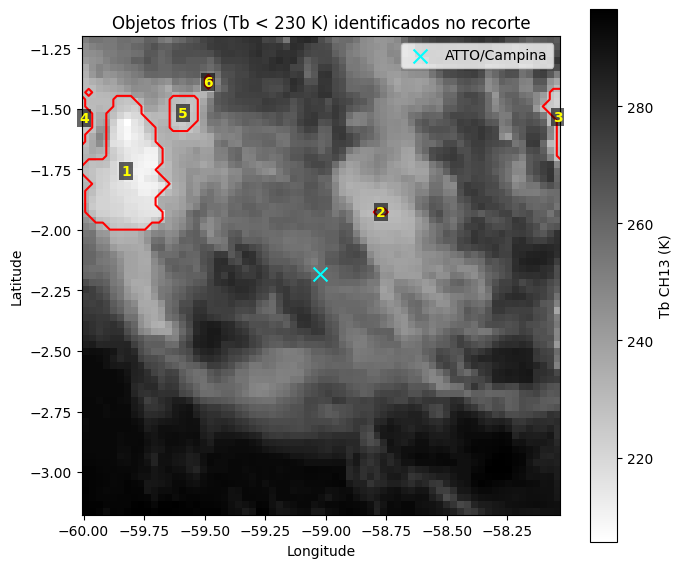

In [17]:


fig, ax = plt.subplots(figsize=(7, 6))

# imagem base
im = ax.imshow(
    patch.values,
    origin="lower",
    cmap="gray_r",
    extent=[
        float(patch.lon.min()),
        float(patch.lon.max()),
        float(patch.lat.min()),
        float(patch.lat.max())
    ]
)

# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Tb CH13 (K)")

# marca a estação
ax.scatter(
    LON_ATTO,
    LAT_ATTO,
    marker="x",
    s=100,
    color="cyan",
    label="ATTO/Campina",
    zorder=5
)

# coordenadas 2D para contornos
lon2d, lat2d = np.meshgrid(patch.lon.values, patch.lat.values)

# desenha cada objeto e escreve o ID
for _, row in df_obj.iterrows():
    obj_id = int(row["obj_id"])
    mask_obj = labels == obj_id

    # contorno do objeto
    ax.contour(
        lon2d,
        lat2d,
        mask_obj,
        levels=[0.5],
        colors="red",
        linewidths=1.5
    )

    # posição do texto no centróide
    x_text = row["lon_centroide"]
    y_text = row["lat_centroide"]

    # texto com ID
    ax.text(
        x_text,
        y_text,
        f"{obj_id}",
        color="yellow",
        fontsize=10,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=1.5)
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Objetos frios (Tb < 230 K) identificados no recorte")
ax.legend()
plt.tight_layout()
plt.show()